In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
df = pd.read_csv("Credit_Risk_Status data.csv")

print(df.head())

   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  Age  \
0                 1                              0.766127   45   
1                 0                              0.957151   40   
2                 0                              0.658180   38   
3                 0                              0.233810   30   
4                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982           9120   
1                                     0   0.121876           2600   
2                                     1   0.085113           3042   
3                                     0   0.036050           3300   
4                                     1   0.024926          63588   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                                4                        0   

In [90]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'Age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'Risk Status'],
      dtype='object')

In [91]:
df.shape

(120121, 12)

In [92]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Risk Status
0,1,0.766127,45,2,0.802982,9120,13,0,6,0,2,Very High
1,0,0.957151,40,0,0.121876,2600,4,0,0,0,1,Low
2,0,0.658180,38,1,0.085113,3042,2,1,0,0,0,High
3,0,0.233810,30,0,0.036050,3300,5,0,0,0,0,Low
4,0,0.907239,49,1,0.024926,63588,7,0,1,0,0,Medium


In [93]:
df = df.rename(columns={
    'SeriousDlqin2yrs': 'Default_in_2yrs',
    'RevolvingUtilizationOfUnsecuredLines': 'CreditUtilization',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Num_30_59_DaysLate',
    'DebtRatio': 'DebtRatio',
    'MonthlyIncome': 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans': 'Num_OpenCreditLinesLoans',
    'NumberOfTimes90DaysLate': 'Num_90_DaysLate',
    'NumberRealEstateLoansOrLines': 'Num_RealEstateLoans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Num_60_89_DaysLate',
    'NumberOfDependents': 'Num_Dependents'
})

print(df.columns)

Index(['Default_in_2yrs', 'CreditUtilization', 'Age', 'Num_30_59_DaysLate',
       'DebtRatio', 'MonthlyIncome', 'Num_OpenCreditLinesLoans',
       'Num_90_DaysLate', 'Num_RealEstateLoans', 'Num_60_89_DaysLate',
       'Num_Dependents', 'Risk Status'],
      dtype='object')


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120121 entries, 0 to 120120
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Default_in_2yrs           120121 non-null  int64  
 1   CreditUtilization         120121 non-null  float64
 2   Age                       120121 non-null  int64  
 3   Num_30_59_DaysLate        120121 non-null  int64  
 4   DebtRatio                 120121 non-null  float64
 5   MonthlyIncome             120121 non-null  int64  
 6   Num_OpenCreditLinesLoans  120121 non-null  int64  
 7   Num_90_DaysLate           120121 non-null  int64  
 8   Num_RealEstateLoans       120121 non-null  int64  
 9   Num_60_89_DaysLate        120121 non-null  int64  
 10  Num_Dependents            120121 non-null  int64  
 11  Risk Status               120121 non-null  object 
dtypes: float64(2), int64(9), object(1)
memory usage: 11.0+ MB


In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Default_in_2yrs,120121.0,0.068872,0.253238,0.0,0.000000,0.000000,0.000000,1.0
CreditUtilization,120121.0,5.905910,257.198929,0.0,0.034980,0.176697,0.577142,50708.0
Age,120121.0,51.308805,14.417793,0.0,41.000000,51.000000,61.000000,103.0
Num_30_59_DaysLate,120121.0,0.261561,0.719067,0.0,0.000000,0.000000,0.000000,13.0
DebtRatio,120121.0,26.631541,424.706830,0.0,0.144104,0.296348,0.482856,61106.5
MonthlyIncome,120121.0,6675.288934,14392.487663,0.0,3400.000000,5400.000000,8250.000000,3008750.0
Num_OpenCreditLinesLoans,120121.0,8.769249,5.166898,0.0,5.000000,8.000000,11.000000,58.0
Num_90_DaysLate,120121.0,0.091508,0.489229,0.0,0.000000,0.000000,0.000000,17.0
Num_RealEstateLoans,120121.0,1.055819,1.149385,0.0,0.000000,1.000000,2.000000,54.0
Num_60_89_DaysLate,120121.0,0.067382,0.336564,0.0,0.000000,0.000000,0.000000,11.0


In [96]:
df.isnull().sum()/len(df) * 100

Default_in_2yrs             0.0
CreditUtilization           0.0
Age                         0.0
Num_30_59_DaysLate          0.0
DebtRatio                   0.0
MonthlyIncome               0.0
Num_OpenCreditLinesLoans    0.0
Num_90_DaysLate             0.0
Num_RealEstateLoans         0.0
Num_60_89_DaysLate          0.0
Num_Dependents              0.0
Risk Status                 0.0
dtype: float64

In [97]:
print(df.nunique())

Default_in_2yrs                  2
CreditUtilization           103063
Age                             83
Num_30_59_DaysLate              14
DebtRatio                   109638
MonthlyIncome                13591
Num_OpenCreditLinesLoans        58
Num_90_DaysLate                 17
Num_RealEstateLoans             28
Num_60_89_DaysLate              11
Num_Dependents                  13
Risk Status                      4
dtype: int64


In [98]:
df.duplicated().sum()

96

In [99]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [100]:
df.dtypes

Default_in_2yrs               int64
CreditUtilization           float64
Age                           int64
Num_30_59_DaysLate            int64
DebtRatio                   float64
MonthlyIncome                 int64
Num_OpenCreditLinesLoans      int64
Num_90_DaysLate               int64
Num_RealEstateLoans           int64
Num_60_89_DaysLate            int64
Num_Dependents                int64
Risk Status                  object
dtype: object

In [101]:
df = df.drop(columns=["Default_in_2yrs"])

C:\Users\ENG-YOSRE\AppData\Local\Temp\ipykernel_20900\1924038950.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


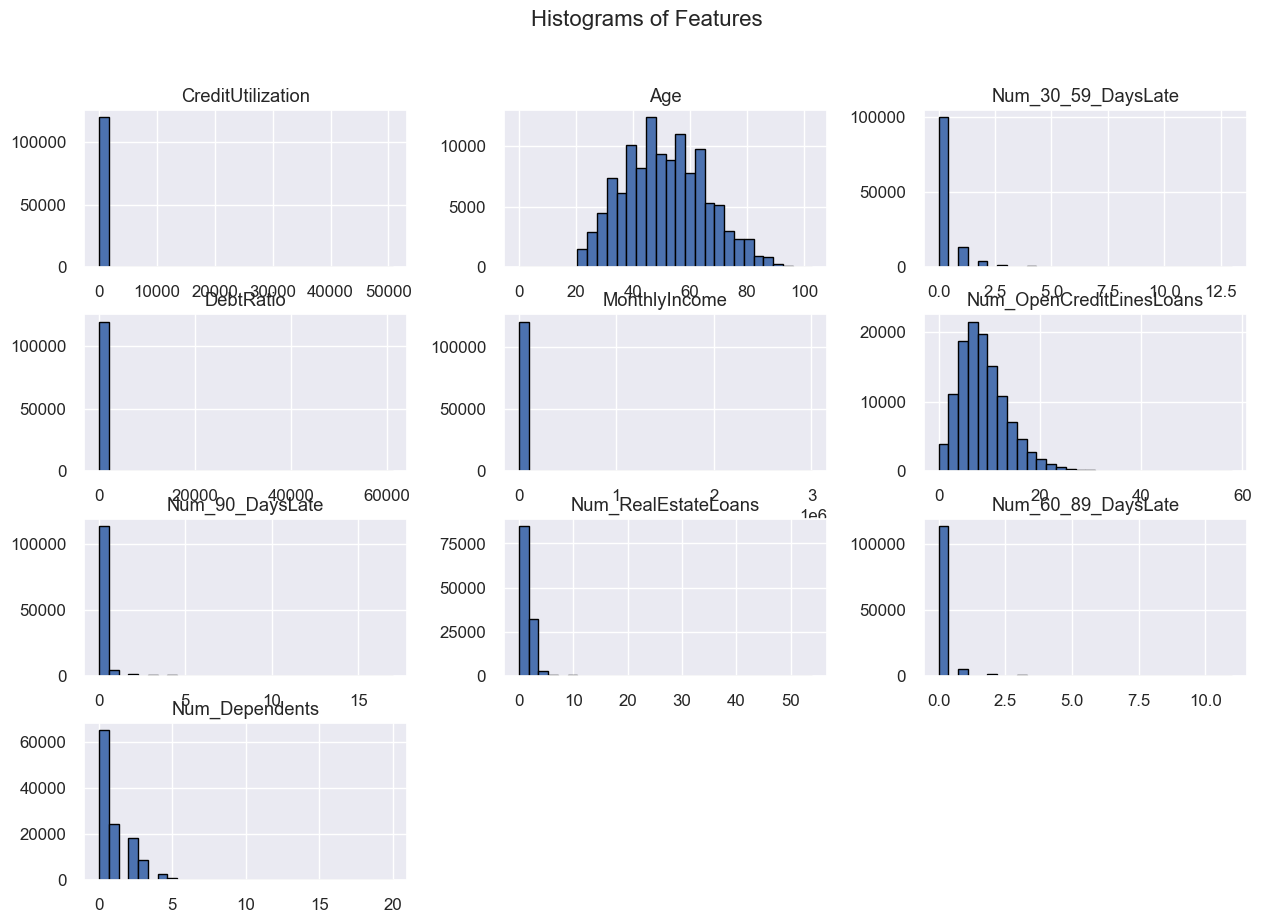

e:\المبادرة\AI\week 5\venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


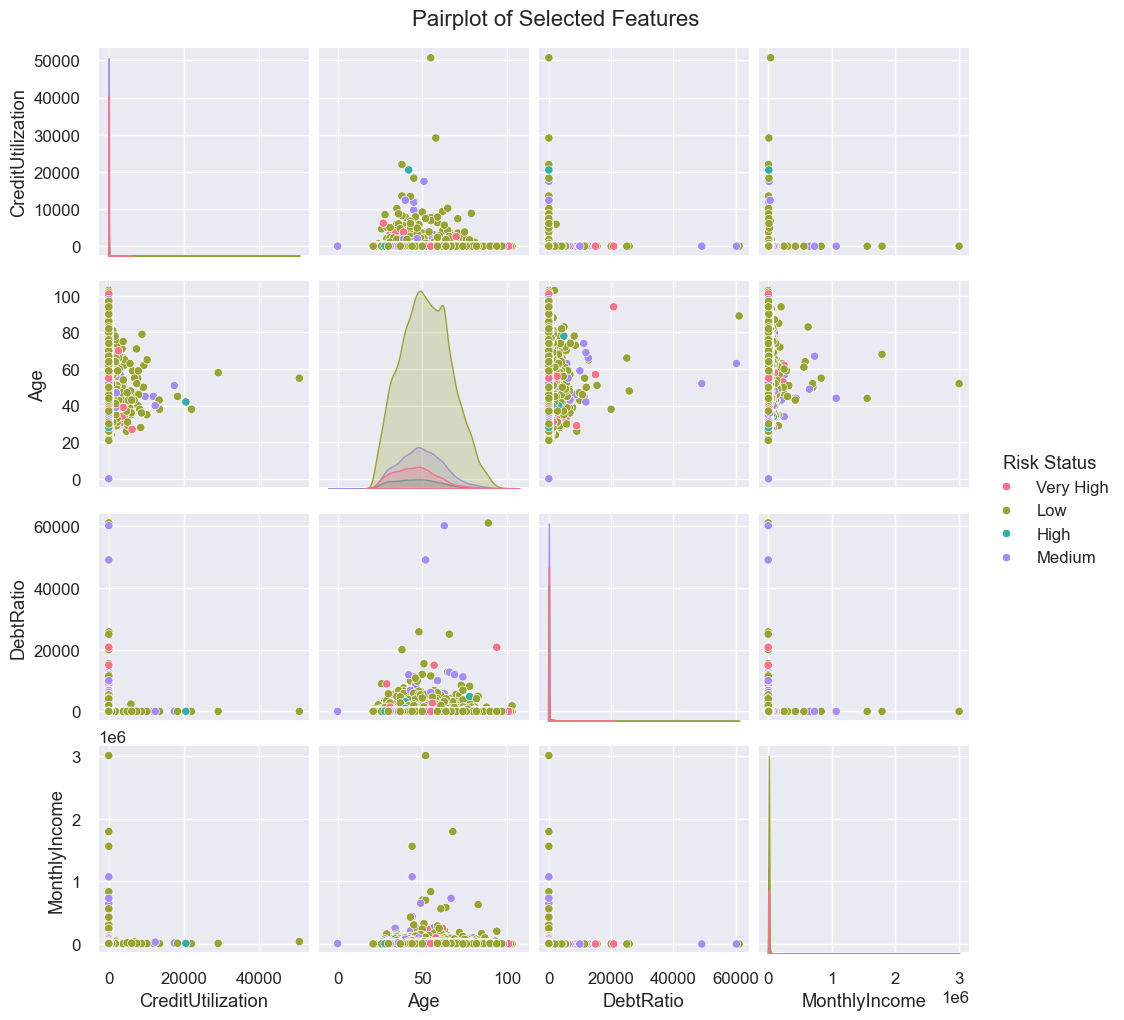

C:\Users\ENG-YOSRE\AppData\Local\Temp\ipykernel_20900\1924038950.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Risk Status", data=df, palette="Set2")


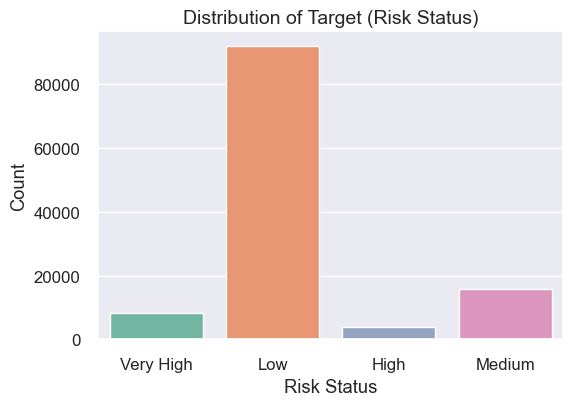

In [103]:
plt.style.use("seaborn")
sns.set(font_scale=1.1)

# 1. Histogram لكل feature
df.hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Histograms of Features", fontsize=16)
plt.show()

# 2. Pairplot
selected_cols = ["CreditUtilization", "Age", "DebtRatio", "MonthlyIncome","Risk Status"]
sns.pairplot(df[selected_cols], hue="Risk Status", diag_kind="kde", palette="husl")
plt.suptitle("Pairplot of Selected Features", y=1.02, fontsize=16)
plt.show()

# 3. Countplot للـ Target
plt.figure(figsize=(6,4))
sns.countplot(x="Risk Status", data=df, palette="Set2")
plt.title("Distribution of Target (Risk Status)", fontsize=14)
plt.xlabel("Risk Status")
plt.ylabel("Count")
plt.show()

CreditUtilization              Axes(0.125,0.747241;0.133621x0.132759)
Age                         Axes(0.285345,0.747241;0.133621x0.132759)
Num_30_59_DaysLate           Axes(0.44569,0.747241;0.133621x0.132759)
DebtRatio                   Axes(0.606034,0.747241;0.133621x0.132759)
MonthlyIncome               Axes(0.766379,0.747241;0.133621x0.132759)
Num_OpenCreditLinesLoans       Axes(0.125,0.587931;0.133621x0.132759)
Num_90_DaysLate             Axes(0.285345,0.587931;0.133621x0.132759)
Num_RealEstateLoans          Axes(0.44569,0.587931;0.133621x0.132759)
Num_60_89_DaysLate          Axes(0.606034,0.587931;0.133621x0.132759)
Num_Dependents              Axes(0.766379,0.587931;0.133621x0.132759)
dtype: object

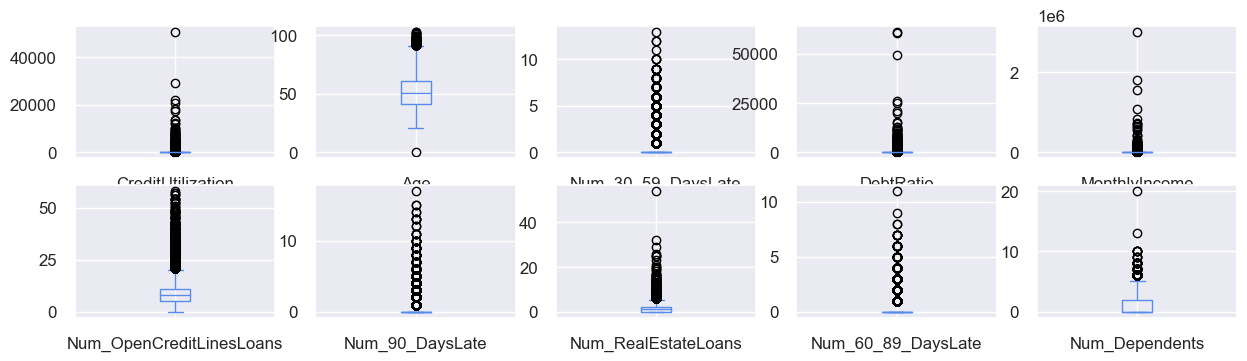

In [104]:
df.plot(kind='box',subplots=True, figsize=(15, 10), color="#578BEC",layout=(5,5))

In [105]:
print(df.columns)


Index(['CreditUtilization', 'Age', 'Num_30_59_DaysLate', 'DebtRatio',
       'MonthlyIncome', 'Num_OpenCreditLinesLoans', 'Num_90_DaysLate',
       'Num_RealEstateLoans', 'Num_60_89_DaysLate', 'Num_Dependents',
       'Risk Status'],
      dtype='object')


In [106]:

# --- Domain-based clipping ---

df['Age'] = df['Age'].clip(lower=18, upper=100)
df['Num_Dependents'] = df['Num_Dependents'].clip(upper=10)
df['CreditUtilization'] = df['CreditUtilization'].clip(lower=0, upper=100)

# --- Percentile-based clipping ---
# Monthly Income 

df['MonthlyIncome'] = df['MonthlyIncome'].clip(
lower=df['MonthlyIncome'].quantile(0.01),
upper=df['MonthlyIncome'].quantile(0.99)
)

# Debt Ratio
df['DebtRatio'] = df['DebtRatio'].clip(
lower=df['DebtRatio'].quantile(0.01),
upper=df['DebtRatio'].quantile(0.99)
)

# Categorical count-like features

df['Num_30_59_DaysLate'] = df['Num_30_59_DaysLate'].clip(upper=10)
df['Num_60_89_DaysLate'] = df['Num_60_89_DaysLate'].clip(upper=10)
df['Num_90_DaysLate'] = df['Num_90_DaysLate'].clip(upper=15)

df['Num_OpenCreditLinesLoans'] = df['Num_OpenCreditLinesLoans'].clip(upper=30)
df['Num_RealEstateLoans'] = df['Num_RealEstateLoans'].clip(upper=20)


CreditUtilization              Axes(0.125,0.747241;0.133621x0.132759)
Age                         Axes(0.285345,0.747241;0.133621x0.132759)
Num_30_59_DaysLate           Axes(0.44569,0.747241;0.133621x0.132759)
DebtRatio                   Axes(0.606034,0.747241;0.133621x0.132759)
MonthlyIncome               Axes(0.766379,0.747241;0.133621x0.132759)
Num_OpenCreditLinesLoans       Axes(0.125,0.587931;0.133621x0.132759)
Num_90_DaysLate             Axes(0.285345,0.587931;0.133621x0.132759)
Num_RealEstateLoans          Axes(0.44569,0.587931;0.133621x0.132759)
Num_60_89_DaysLate          Axes(0.606034,0.587931;0.133621x0.132759)
Num_Dependents              Axes(0.766379,0.587931;0.133621x0.132759)
dtype: object

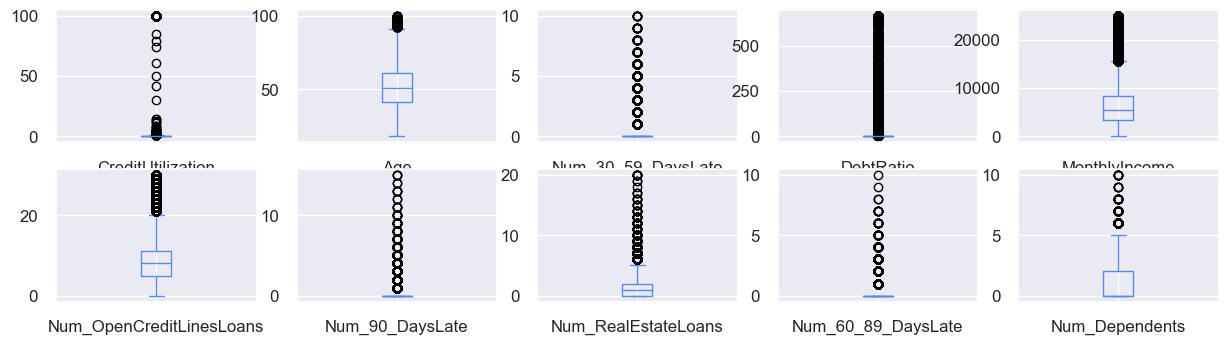

In [107]:
df.plot(kind='box',subplots=True, figsize=(15, 10), color="#578BEC",layout=(5,5))

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

df["Risk_Status_Binary"] = df["Risk Status"].replace({
    "Low": "Low",
    "Medium": "Risky",
    "High": "Risky",
    "Very High": "Risky"
})

encoder = LabelEncoder()
df["Risk_Status_Binary"] = encoder.fit_transform(df["Risk_Status_Binary"])

X = df.drop(['Risk_Status_Binary', 'Risk Status'], axis=1)
y = df['Risk_Status_Binary']

print(df["Risk_Status_Binary"].value_counts())

Risk_Status_Binary
0    91948
1    28077
Name: count, dtype: int64


C:\Users\ENG-YOSRE\AppData\Local\Temp\ipykernel_20900\2367004483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Risk_Status_Binary", data=df, palette="Set2")


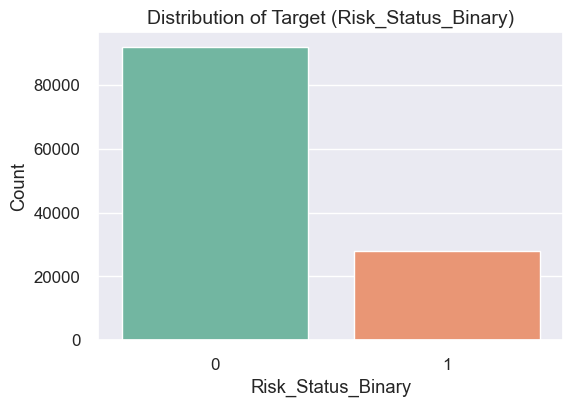

In [109]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Status_Binary", data=df, palette="Set2")
plt.title("Distribution of Target (Risk_Status_Binary)", fontsize=14)
plt.xlabel("Risk_Status_Binary")
plt.ylabel("Count")
plt.show()

Correlation Matrix
                          CreditUtilization       Age  Num_30_59_DaysLate  \
CreditUtilization                  1.000000 -0.033144            0.018824   
Age                               -0.033144  1.000000           -0.061292   
Num_30_59_DaysLate                 0.018824 -0.061292            1.000000   
DebtRatio                         -0.001002 -0.019518           -0.006976   
MonthlyIncome                      0.006880  0.107741           -0.005054   
Num_OpenCreditLinesLoans          -0.036471  0.185560            0.069585   
Num_90_DaysLate                    0.022005 -0.076577            0.220158   
Num_RealEstateLoans                0.000186  0.063631            0.036572   
Num_60_89_DaysLate                 0.016002 -0.063383            0.305667   
Num_Dependents                     0.008966 -0.208867            0.058507   
Risk_Status_Binary                 0.025737 -0.124123            0.659320   

                          DebtRatio  MonthlyIncome  Num_

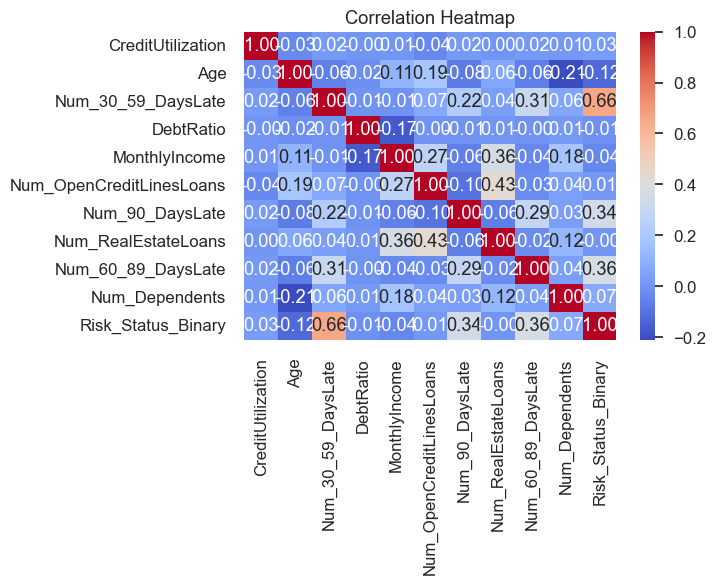

In [110]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

print("Correlation Matrix")
print(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 73558, 1: 22462}
After SMOTE: {1: 73558, 0: 73558}


In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(lr, n_features_to_select=5)
fit = rfe.fit(X_train_res, y_train_res)

selected_features = X_train_res.columns[fit.support_]
print("\nSelected Features:", list(selected_features))

# Train using only selected features
X_train_sel = X_train_res[selected_features]
X_test_sel = X_test[selected_features]

lr.fit(X_train_sel, y_train_res)
y_pred_lr = lr.predict(X_test_sel)

print("\n--- Logistic Regression ---")
print("Train Accuracy:", accuracy_score(y_train_res, lr.predict(X_train_sel)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

e:\المبادرة\AI\week 5\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Selected Features: ['Num_30_59_DaysLate', 'Num_90_DaysLate', 'Num_RealEstateLoans', 'Num_60_89_DaysLate', 'Num_Dependents']

--- Logistic Regression ---
Train Accuracy: 0.880414094999864
Test Accuracy: 0.9767131847531764
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     18390
           1       1.00      0.90      0.95      5615

    accuracy                           0.98     24005
   macro avg       0.99      0.95      0.97     24005
weighted avg       0.98      0.98      0.98     24005

Confusion Matrix:
 [[18390     0]
 [  559  5056]]


In [113]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_sel, y_train_res)
y_pred_rf = rf.predict(X_test_sel)

print("\n--- Random Forest ---")
print("Train Accuracy:", accuracy_score(y_train_res, rf.predict(X_train_sel)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



--- Random Forest ---
Train Accuracy: 0.8804888659289268
Test Accuracy: 0.9764632368256613
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     18390
           1       1.00      0.90      0.95      5615

    accuracy                           0.98     24005
   macro avg       0.98      0.95      0.97     24005
weighted avg       0.98      0.98      0.98     24005

Confusion Matrix:
 [[18384     6]
 [  559  5056]]


In [114]:

numeric_df = df.select_dtypes(include=['number'])

# Compute correlation with target
corr = numeric_df.corr()["Risk_Status_Binary"].sort_values(ascending=False)

print("\n🔎 Top correlations with Risk_Status_Binary:")
print(corr.head(10))



🔎 Top correlations with Risk_Status_Binary:
Risk_Status_Binary          1.000000
Num_30_59_DaysLate          0.659320
Num_60_89_DaysLate          0.362689
Num_90_DaysLate             0.338916
Num_Dependents              0.070171
CreditUtilization           0.025737
Num_OpenCreditLinesLoans    0.012777
Num_RealEstateLoans        -0.000473
DebtRatio                  -0.012771
MonthlyIncome              -0.041171
Name: Risk_Status_Binary, dtype: float64


Epoch 1/20


e:\المبادرة\AI\week 5\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4598/4598 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8776 - loss: 0.3199 - val_accuracy: 0.9766 - val_loss: 0.2211
Epoch 2/20
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8804 - loss: 0.2997 - val_accuracy: 0.9766 - val_loss: 0.1849
Epoch 3/20
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8804 - loss: 0.2994 - val_accuracy: 0.9767 - val_loss: 0.2239
Epoch 4/20
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8804 - loss: 0.2987 - val_accuracy: 0.9767 - val_loss: 0.1869
Epoch 5/20
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8804 - loss: 0.2982 - val_accuracy: 0.9766 - val_loss: 0.2068
751/751 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step

--- Deep Learning Model ---
Accuracy: 0.9765882107894188
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     18390
           1       1.00      0.90      0.95      5615

    accuracy                           0.98     24005
   macro avg      

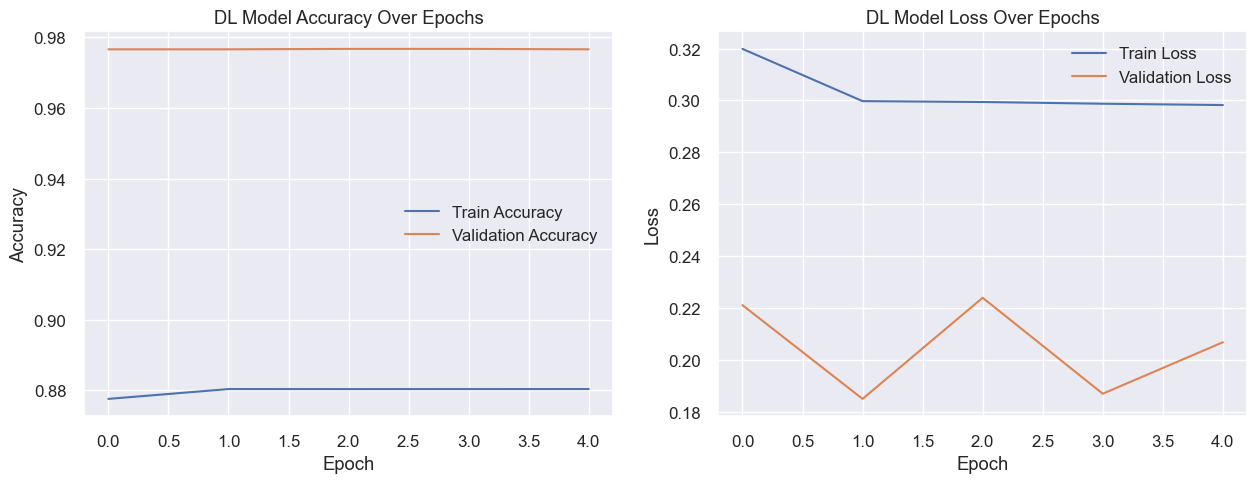

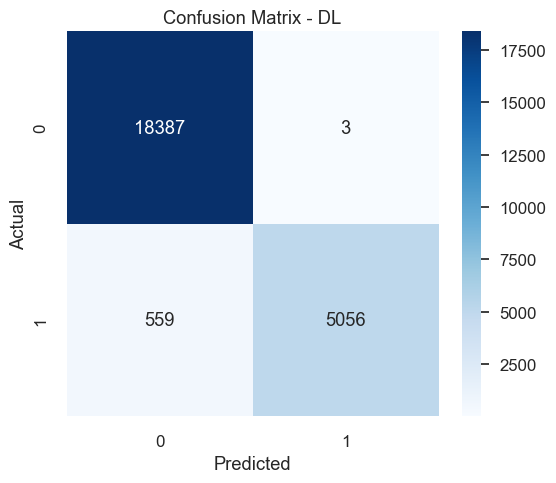

In [115]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

dl_model = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = dl_model.fit(
    X_train_scaled, y_train_res,
    epochs=20, batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

y_pred_dl = (dl_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()

print("\n--- Deep Learning Model ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dl))
print("Classification Report:\n", classification_report(y_test, y_pred_dl))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))

# ------------------------------
# 7. Visualization
# ------------------------------
plt.figure(figsize=(15,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DL Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DL Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_dl), annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix - DL")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import pandas as pd

# 1. Select features first
X_selected = df[selected_features]
y = df["Risk_Status_Binary"]

# 2. Train/test split
from sklearn.model_selection import train_test_split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train_sel.shape, y_train_sel.shape)
print(X_test_sel.shape, y_test_sel.shape)

# ==============================================================
# Train Multiple Models After Feature Selection
# ==============================================================

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    #"SVM": SVC(kernel="rbf", probability=True, class_weight="balanced"),  # Optional
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = {}

# Loop over models
for name, model in models.items():
    print("="*50)
    print(f"▶ Training {name}")
    model.fit(X_train_sel, y_train_sel)
    y_pred_sel = model.predict(X_test_sel)

    train_acc = accuracy_score(y_train_sel, model.predict(X_train_sel))
    test_acc = accuracy_score(y_test_sel, y_pred_sel)

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("Classification Report:\n", classification_report(y_test_sel, y_pred_sel))

    cm = confusion_matrix(y_test_sel, y_pred_sel)
    print("Confusion Matrix:\n", cm)

    # Save results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Confusion Matrix": cm
    }

# Convert results to DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\n\n Summary of Results:")
print(results_df)


(84017, 5) (84017,)
(36008, 5) (36008,)
▶ Training Logistic Regression
Train Accuracy: 0.9766
Test Accuracy: 0.9770
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     27585
           1       1.00      0.90      0.95      8423

    accuracy                           0.98     36008
   macro avg       0.99      0.95      0.97     36008
weighted avg       0.98      0.98      0.98     36008

Confusion Matrix:
 [[27585     0]
 [  827  7596]]
▶ Training Random Forest
Train Accuracy: 0.9767
Test Accuracy: 0.9767
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     27585
           1       1.00      0.90      0.95      8423

    accuracy                           0.98     36008
   macro avg       0.98      0.95      0.97     36008
weighted avg       0.98      0.98      0.98     36008

Confusion Matrix:
 [[27573    12]
 [  827  7596]]
▶ Training K

e:\المبادرة\AI\week 5\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:13:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy: 0.9767
Test Accuracy: 0.9769
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     27585
           1       1.00      0.90      0.95      8423

    accuracy                           0.98     36008
   macro avg       0.99      0.95      0.97     36008
weighted avg       0.98      0.98      0.98     36008

Confusion Matrix:
 [[27581     4]
 [  827  7596]]


 Summary of Results:
                    Train Accuracy Test Accuracy            Confusion Matrix
Logistic Regression       0.976612      0.977033   [[27585, 0], [827, 7596]]
Random Forest             0.976683        0.9767  [[27573, 12], [827, 7596]]
KNN                       0.976386      0.976283  [[27572, 13], [841, 7582]]
Gradient Boosting         0.976659      0.976922   [[27581, 4], [827, 7596]]
XGBoost                   0.976671      0.976922   [[27581, 4], [827, 7596]]
